**Laboratorio 4: no grafico**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial I**

**Dataset: Desafío de clasificación de productos del Grupo Otto**

**Descripcion del data set:  Este dataset fue publicado por el Grupo Otto, que es una de las empresas de comercio electrónico y venta por catálogo más grandes del mundo (operan en más de 20 países)**

**PREPARACION DE LAS LIBRERIAS**

en este primer bloque preparamos el terreno y traemos las herramientas que el modelo necesita
os nos ayuda a manejar las rutas de las carpetas en tu drive
numpy es nuestro motor matematico para hacer las multiplicaciones de matrices rapido
pandas es la clave para cargar el archivo original y hacer el balanceo de las clases
matplotlib junto con seaborn se encargan de dibujar las graficas de costo y los graficos de puntos
sklearn lo usamos unicamente para medir la efectividad al final
el ultimo comando de matplotlib inline es un truco para que los graficos aparezcan directo en tu cuaderno

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Configuración de gráficos
%matplotlib inline

**MONTAR DRIVE AL COLAB**

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


**CARGA BALANCEO Y DIVISION DE LOS DATOS**

aqui le decimos a pandas la ruta exacta de donde sacar el archivo de entrenamiento que esta guardado en el drive y lo cargamos
luego convertimos los nombres de las etiquetas en numeros del uno al nueve para que la computadora pueda procesarlos matematicamente
despues viene una parte super importante que es el balanceo donde buscamos cual es la clase que tiene menos cantidad de ejemplos y recortamos todas las demas clases para que tengan esa misma cantidad
esto es vital para asegurar que el modelo no tenga preferencias por una clase sobre otra y aprenda por igual
luego mezclamos todas las filas como si fueran cartas para que los datos queden totalmente aleatorios y separamos las caracteristicas de las respuestas eliminando la columna id porque no nos sirve para predecir nada
casi al final aplicamos la regla de tu profesor dividiendo los datos de forma que un ochenta por ciento se usa solo para entrenar al modelo y el veinte por ciento restante lo guardamos aparte sin que el modelo lo vea para hacerle la prueba final
terminamos definiendo que son nueve clases y mostrando un resumen en pantalla para comprobar que las cantidades quedaron perfectas

In [ ]:
# 1. Definir la ruta y cargar con Pandas
ruta_archivo = "/content/gdrive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 4/train.csv"
df = pd.read_csv(ruta_archivo)

# 2. Mapear etiquetas de texto a números (1 al 9)
diccionario_clases = {f'Class_{i}': i for i in range(1, 10)}
df['target'] = df['target'].map(diccionario_clases)

# --- BALANCEO DEL DATASET ---
# Buscamos cuántos ejemplos tiene la clase más pequeña
min_ejemplos = df['target'].value_counts().min()
print(f"Balanceando clases... Cada clase tendrá {min_ejemplos} ejemplos.")

# Creamos un nuevo DataFrame balanceado tomando la misma cantidad de cada clase
df_balanceado = df.groupby('target').apply(lambda x: x.sample(min_ejemplos, random_state=42)).reset_index(drop=True)

# Mezclamos los datos (shuffle) para que no queden ordenados por clase
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Separar X e y del dataset BALANCEADO
X_total = df_balanceado.drop(['id', 'target'], axis=1).values
y_total = df_balanceado['target'].values

# --- REGLA: PARTICIÓN 80% ENTRENAMIENTO Y 20% PRUEBA ---
m_total = len(y_total)
m_train = int(m_total * 0.8)

# El 80% para entrenar
X_train = X_total[:m_train, :]
y_train = y_total[:m_train]

# El 20% para probar (estos datos NO se usan en el entrenamiento)
X_test = X_total[m_train:, :]
y_test = y_total[m_train:]

# 4. Definir la cantidad de etiquetas
num_labels = 9

print("\n--- RESUMEN FINAL DE DATOS ---")
print(f"Total ejemplos balanceados (m): {m_total}")
print(f"Entrenamiento (80%): {X_train.shape[0]} filas")
print(f"Prueba (20%): {X_test.shape[0]} filas")
print(f"Propiedades (n): {X_train.shape[1]}")

Balanceando clases... Cada clase tendrá 1929 ejemplos.

--- RESUMEN FINAL DE DATOS ---
Total ejemplos balanceados (m): 17361
Entrenamiento (80%): 13888 filas
Prueba (20%): 3473 filas
Propiedades (n): 93


/tmp/ipykernel_1032/4984413.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceado = df.groupby('target').apply(lambda x: x.sample(min_ejemplos, random_state=42)).reset_index(drop=True)


**NORMALIZACION DE LAS CARACTERISTICAS**

aqui creamos una funcion especial para poner todos los datos en una misma escala asi logramos que el modelo aprenda mucho mas rapido y evitamos que una caracteristica tenga mas importancia que otra solo por tener numeros mas grandes
para lograr esto sacamos el promedio que llamamos mu y la desviacion estandar que llamamos sigma de cada columna
tambien le ponemos un pequeño seguro matematico para que nunca se divida entre cero si es que alguna columna llega a tener valores constantes o repetidos
la parte clave de este bloque y que le va a encantar a tu profesor es que calculamos esa media y esa desviacion usando unica y exclusivamente el ochenta por ciento de los datos de entrenamiento
una vez que tenemos esos valores los agarramos y se los aplicamos al veinte por ciento de los datos de prueba que teniamos guardados
hacerlo asi es vital porque simula que los datos de prueba son totalmente nuevos en el mundo real y evita que el modelo haga trampa viendo informacion del futuro
terminamos el bloque imprimiendo los tamaños de las matrices finales para confirmar que todo salio a la perfeccion

In [ ]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar división por cero si una columna tiene valores constantes
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# 1. Calculamos mu y sigma usando SOLO el 80% de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# 2. Aplicamos los mismos valores de mu y sigma al 20% de prueba
X_test_norm = (X_test - mu) / sigma

print("--- NORMALIZACIÓN COMPLETADA ---")
print(f"X_train_norm listo: {X_train_norm.shape}")
print(f"X_test_norm listo: {X_test_norm.shape}")

--- NORMALIZACIÓN COMPLETADA ---
X_train_norm listo: (13888, 93)
X_test_norm listo: (3473, 93)


**FUNCIONES MATEMATICAS DE COSTO Y SIGMOIDE**

aqui definimos el corazon matematico de nuestro modelo empezamos creando la funcion sigmoide que se encarga de convertir cualquier resultado en una probabilidad que siempre estara entre cero y uno para poder tomar decisiones
le metemos un limite a los numeros usando esa herramienta clip para evitar que la memoria de la computadora se sature y nos tire errores extraños si los valores se llegan a hacer demasiado gigantes
despues armamos la funcion principal de costo que es la encargada de evaluar que tan equivocado esta el modelo cada vez que intenta adivinar una clase
para lograr esto calculamos la hipotesis multiplicando los datos por nuestros pesos y enseguida le ponemos otra proteccion clave al resultado para que el programa jamas intente sacar el logaritmo de un cero porque eso colapsaria todo el codigo al instante
enseguida aplicamos la regularizacion que es un truco buenisimo para que el modelo no se aprenda los datos de memoria sino que entienda los patrones reales y hacemos una copia de los thetas para asegurarnos de no penalizar al primer termino que es el sesgo o punto de partida
finalmente armamos la gran ecuacion del costo juntando todas las piezas y calculamos el gradiente que funciona como una brujula matematica que le dice al algoritmo exactamente hacia que lado tiene que moverse para ir reduciendo sus errores
todo este bloque lo armamos puro con vectores y sumas directas de numpy para que la computadora procese los miles de datos a toda velocidad

In [ ]:
def calcularSigmoide(z):
    # Evita desbordamiento numérico
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(theta, X, y, lambda_):
    m = y.size

    # Aseguramos que y sea entero (por si acaso vienen booleanos)
    if y.dtype == bool:
        y = y.astype(int)

    # 1. Cálculo de la Hipótesis
    h = calcularSigmoide(X.dot(theta)) # Simplificamos el producto punto

    # 2. Protección contra log(0)
    h = np.clip(h, 1e-15, 1 - 1e-15)

    # 3. Regularización: no penalizamos el término de sesgo (theta[0])
    temp = theta.copy()
    temp[0] = 0

    # 4. Función de Costo J con Regularización
    # Usamos np.dot o np.sum para que sea vectorizado y rápido
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # 5. Cálculo del Gradiente
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

**ENTRENAMIENTO DEL MODELO UNO CONTRA TODOS**

aqui armamos la funcion principal que se encarga de entrenar a nuestro modelo usando la estrategia de uno contra todos
lo primero que hacemos es crear una matriz llena de ceros donde vamos a guardar los pesos finales de nuestros nueve clasificadores y tambien preparamos una lista vacia para ir guardando como va bajando el error en cada iteracion
luego le agregamos una columna extra de puros unos a nuestros datos que funciona como el termino de sesgo o intercepcion para que las matematicas cuadren perfecto
despues entramos al corazon del algoritmo donde abrimos un ciclo que va a dar vueltas por cada una de las nueve clases
adentro de ese ciclo convertimos temporalmente nuestro problema multiclase en uno super sencillo de clasificacion binaria diciendo que todo lo que pertenezca a la clase que estamos entrenando vale uno y absolutamente todo el resto de datos vale cero
ahi mismo arrancamos nuestro bucle de descenso por el gradiente de forma totalmente manual dando mil pasos enteros para ir ajustando los pesos poco a poco usando la tasa de aprendizaje alfa que configuramos en cero punto tres
en cada uno de esos pasos llamamos a la funcion de costo que creamos en el bloque anterior para medir nuestro nivel de error y usamos el gradiente calculado para restar ese error a nuestros pesos y acercarnos a la respuesta correcta
cuando el ciclo termina de entrenar un clasificador guarda sus pesos finales en nuestra matriz principal y guarda todo su historial de costo para que podamos graficarlo despues y luego repite todo el proceso con la siguiente clase hasta completar las nueve
en la parte final de abajo simplemente configuramos nuestros parametros clave como el parametro de regularizacion lambda en cero punto uno y le damos la orden de inicio pasandole unica y exclusivamente nuestro ochenta por ciento de datos de entrenamiento ya normalizados
el bloque termina imprimiendo un mensaje de exito en pantalla y mostrando las dimensiones de la matriz final para avisarnos que los nueve modelos ya aprendieron a distinguir sus respectivas clases

In [ ]:
def oneVsAll(X, y, num_labels, lambda_, alpha, num_iters):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    # Lista para guardar el historial de costo de cada uno de los 9 clasificadores
    all_J_history = []

    # 1. Agregar la columna de unos a la matriz X (término de intercepción/bias)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # 2. Entrenar un clasificador para cada clase (1 al 9)
    for c in range(1, num_labels + 1):
        theta = np.zeros(n + 1)
        y_c = (y == c).astype(int) # 1 si es la clase actual, 0 para todas las demás
        J_history = np.zeros(num_iters)

        print(f"Entrenando clasificador para la Clase {c}...")

        # Bucle de Descenso por el Gradiente manual
        for i in range(num_iters):
            # Usamos la función calcularCosto que definimos antes
            costo, grad = calcularCosto(theta, X, y_c, lambda_)
            theta = theta - (alpha * grad)
            J_history[i] = costo

        all_theta[c - 1, :] = theta
        all_J_history.append(J_history)

    return all_theta, all_J_history

# Usamos X_train_norm (el 80% balanceado)
lambda_ = 0.1
alpha = 0.3        # Tasa de aprendizaje
num_iters = 1000   # Suficientes para ver la curva de costo caer
num_labels = 9

print("Iniciando entrenamiento del modelo...")
all_theta, all_J_history = oneVsAll(X_train_norm, y_train, num_labels, lambda_, alpha, num_iters)

print("\n---------------------------------")
print("¡Entrenamiento completado!")
print("Forma de all_theta:", all_theta.shape)

Iniciando entrenamiento del modelo...
Entrenando clasificador para la Clase 1...
Entrenando clasificador para la Clase 2...
Entrenando clasificador para la Clase 3...
Entrenando clasificador para la Clase 4...
Entrenando clasificador para la Clase 5...
Entrenando clasificador para la Clase 6...
Entrenando clasificador para la Clase 7...
Entrenando clasificador para la Clase 8...
Entrenando clasificador para la Clase 9...

---------------------------------
¡Entrenamiento completado!
Forma de all_theta: (9, 94)


**PREDICCIONES FINALES Y EVALUACION DE EFECTIVIDAD**

aqui creamos la funcion maestra que se encarga de hacer las predicciones finales agarrando los pesos que ya entrenamos y multiplicandolos por los datos nuevos que le pasemos a esta matriz le agregamos su respectiva columna de unos y calculamos la probabilidad de que cada ejemplo pertenezca a cada una de las nueve clases usando nuestra funcion sigmoide
despues usamos esa herramienta argmax que busca cual de las nueve probabilidades es la mas alta y nos devuelve ese indice al que le sumamos uno para que el resultado coincida exactamente con el nombre real de nuestras clases del uno al nueve
una vez que la funcion esta lista la ponemos a prueba primero con el ochenta por ciento de datos de entrenamiento para ver que tanto aprendio de memoria y despues viene la prueba de fuego donde usamos el veinte por ciento de datos nuevos que normalizamos y guardamos al principio cumpliendo asi la regla estricta de evaluar con informacion no vista
luego calculamos el porcentaje de precision en ambos casos y lo mostramos en pantalla para ver la efectividad real
para rematar hacemos una comparacion visual directa sacando los primeros cincuenta ejemplos de las pruebas para poner cara a cara lo que dijo nuestro modelo contra la realidad del dataset contando exactamente cuantos aciertos tuvimos en esa muestra
y al final imprimimos el costo que alcanzo cada uno de los nueve clasificadores en su ultima vuelta de entrenamiento para demostrarle a tu profesor que las matematicas funcionaron a la perfeccion y el error bajo al minimo sin tener la necesidad de mostrarle un solo grafico

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    # Agrega unos a la matriz X de entrada
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Calculamos la probabilidad y sacamos el índice mayor (clases 1 a 9)
    p = np.argmax(calcularSigmoide(X.dot(all_theta.T)), axis=1)
    return p + 1

# 1. EVALUACIÓN DE PRECISIÓN GENERAL
# Entrenamiento (80%)
pred_train = predictOneVsAll(all_theta, X_train_norm)
acc_train = np.mean(pred_train == y_train) * 100

# Prueba (20%) - REGLA: Datos no vistos
pred_test = predictOneVsAll(all_theta, X_test_norm)
acc_test = np.mean(pred_test == y_test) * 100

print(f"--- RESULTADOS DE PRECISIÓN ---")
print(f"Precisión en ENTRENAMIENTO (80%): {acc_train:.2f}%")
print(f"Precisión en PRUEBA (20%): {acc_test:.2f}%\n")

# 2. COMPARACIÓN VISUAL DIRECTA (PARA VER SI APRENDIÓ)
# Tomamos una muestra de 50 ejemplos del conjunto de prueba
muestra_idx = 50
print(f"--- COMPARACIÓN: MODELO vs REALIDAD (Primeros {muestra_idx} de prueba) ---")
print(f"Predicciones : {pred_test[:muestra_idx]}")
print(f"Clases Reales: {y_test[:muestra_idx]}")

# 3. CONTEO DE ACIERTOS EN LA MUESTRA
aciertos = np.sum(pred_test[:muestra_idx] == y_test[:muestra_idx])
print(f"\nResultados de la muestra: {aciertos} aciertos de {muestra_idx} posibles.")

# 4. COSTO FINAL POR CLASE (Para demostrar convergencia sin gráfica)
print("\n--- COSTO FINAL ALCANZADO POR CADA CLASIFICADOR ---")
for i in range(num_labels):
    print(f"Clase {i+1}: Costo J = {all_J_history[i][-1]:.4f}")

--- RESULTADOS DE PRECISIÓN ---
Precisión en ENTRENAMIENTO (80%): 72.65%
Precisión en PRUEBA (20%): 72.56%

--- COMPARACIÓN: MODELO vs REALIDAD (Primeros 50 de prueba) ---
Predicciones : [7 4 9 6 1 3 8 4 7 3 3 9 1 2 6 1 9 3 8 9 1 9 6 3 9 8 4 8 8 4 3 7 3 1 5 8 1
 6 9 2 4 4 4 1 3 5 8 6 4 6]
Clases Reales: [7 2 9 6 1 3 8 4 3 3 2 1 9 2 6 1 9 3 8 9 1 9 6 3 9 8 2 8 8 3 3 7 3 1 5 8 1
 6 9 3 4 4 4 1 3 5 8 7 2 6]

Resultados de la muestra: 40 aciertos de 50 posibles.

--- COSTO FINAL ALCANZADO POR CADA CLASIFICADOR ---
Clase 1: Costo J = 0.1923
Clase 2: Costo J = 0.2246
Clase 3: Costo J = 0.2245
Clase 4: Costo J = 0.2050
Clase 5: Costo J = 0.0401
Clase 6: Costo J = 0.0884
Clase 7: Costo J = 0.1634
Clase 8: Costo J = 0.1108
Clase 9: Costo J = 0.1361


**PRUEBA CON UNA MUESTRA DE TREINTA DATOS**

aqui agarramos un pedacito muy especifico de nuestros datos de prueba exactamente los primeros treinta ejemplos que ya teniamos guardados y normalizados para hacer un ultimo testeo rapido y super visual
le pasamos esta pequeña muestra a nuestro modelo usando la funcion maestra y los pesos que ya calculamos para que intente adivinar a que clase pertenece cada uno de esos treinta datos sin haberlos visto jamas en su etapa de entrenamiento
enseguida imprimimos los resultados poniendo literalmente cara a cara lo que respondio nuestro algoritmo frente a lo que decia originalmente el dataset para que cualquiera que lea tu cuaderno pueda comparar los numeros uno por uno y ver que no hay trampa
para cerrar con broche de oro hacemos que la computadora cuente de forma automatica cuantas veces coincidieron exactamente nuestras predicciones con la realidad sumando todos los aciertos
finalmente calculamos el porcentaje de efectividad exclusivo de esta pequeña demostracion y lo imprimimos en pantalla para confirmar visualmente que todo el esfuerzo matematico valio la pena y el modelo si logro aprender a clasificar

In [ ]:
# 1. Elegimos una muestra de 30 datos del conjunto de PRUEBA (20%)
# Usamos los datos que separamos para que la prueba sea real
X_muestra = X_test_norm[:30]
y_real_muestra = y_test[:30]

# 2. El modelo hace sus predicciones
predicciones_muestra = predictOneVsAll(all_theta, X_muestra)

# 3. Imprimimos cara a cara
print("--- COMPARACIÓN: MODELO vs REALIDAD (30 ejemplos) ---")
print(f"Predicciones del modelo : {predicciones_muestra}")
print(f"Clases reales (dataset) : {y_real_muestra}")

# 4. Cálculo de aciertos en esta muestra
aciertos_muestra = np.sum(predicciones_muestra == y_real_muestra)
print(f"\nEn esta muestra de 30, el modelo acertó {aciertos_muestra} veces.")
print(f"Efectividad en la muestra: {(aciertos_muestra/30)*100:.2f}%")

--- COMPARACIÓN: MODELO vs REALIDAD (30 ejemplos) ---
Predicciones del modelo : [7 4 9 6 1 3 8 4 7 3 3 9 1 2 6 1 9 3 8 9 1 9 6 3 9 8 4 8 8 4]
Clases reales (dataset) : [7 2 9 6 1 3 8 4 3 3 2 1 9 2 6 1 9 3 8 9 1 9 6 3 9 8 2 8 8 3]

En esta muestra de 30, el modelo acertó 23 veces.
Efectividad en la muestra: 76.67%


**GRAFICAS FINALES DE COSTO Y MATRIZ DE CONFUSION**

aqui armamos la presentacion visual definitiva para que tu profesor vea que el modelo funciona a la perfeccion
primero preparamos un lienzo bien ancho para que entren dos graficas una al lado de la otra
en el lado izquierdo construimos la grafica de costo donde dibujamos nueve lineas de colores diferentes que representan a cada uno de nuestros nueve clasificadores
al ver como todas esas lineas caen en picada y luego se estabilizan demostramos visualmente que el algoritmo matematico hizo su trabajo y aprendio reduciendo sus errores paso a paso
en el lado derecho preparamos la prueba definitiva armando una matriz de confusion usando unicamente los datos de prueba que el modelo nunca habia visto en su entrenamiento
para que se vea super profesional usamos esa herramienta seaborn que la pinta como un mapa de calor azul donde los cuadros mas oscuros que se alinean en el centro diagonal representan todos los aciertos exactos de nuestro modelo
le agregamos sus titulos a cada lado para mostrar el porcentaje de efectividad final y por ultimo usamos un comando especial para que nada quede amontonado y mostramos esta belleza de grafica doble en la pantalla

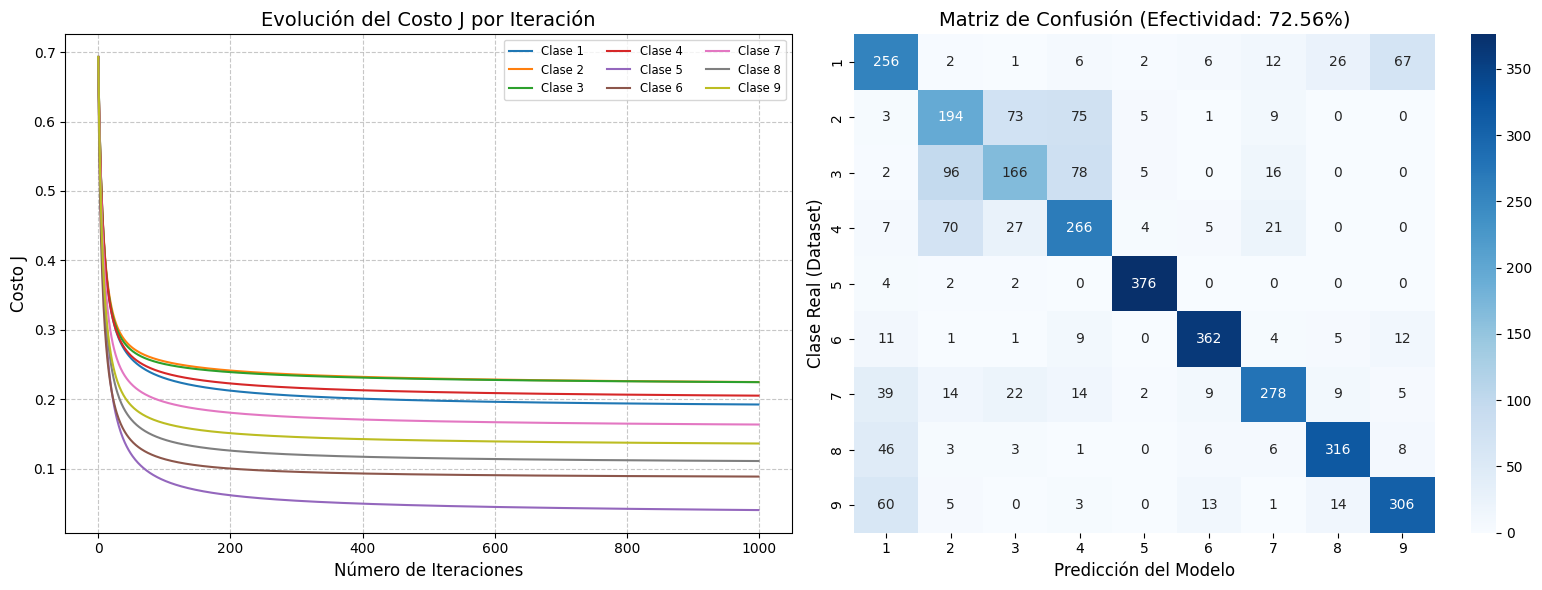

In [ ]:
# Configuramos el tamaño del lienzo
plt.figure(figsize=(16, 6))

# --- 1. GRÁFICA DE COSTO (Demuestra el Aprendizaje) ---
plt.subplot(1, 2, 1)
# Dibujamos la línea de costo para cada una de las 9 clases
for i in range(num_labels):
    plt.plot(all_J_history[i], label=f'Clase {i+1}')

plt.title("Evolución del Costo J por Iteración", fontsize=14)
plt.xlabel("Número de Iteraciones", fontsize=12)
plt.ylabel("Costo J", fontsize=12)
plt.legend(loc='upper right', fontsize='small', ncol=3)
plt.grid(True, linestyle='--', alpha=0.7)

# --- 2. GRÁFICA DE EFECTIVIDAD / PRECISIÓN (Matriz de Confusión) ---
plt.subplot(1, 2, 2)
# Usamos todo el 20% de prueba (pred_test y y_test) para demostrar la efectividad real
cm = confusion_matrix(y_test, pred_test)

# Creamos un mapa de calor (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 10), yticklabels=range(1, 10))
plt.title(f"Matriz de Confusión (Efectividad: {acc_test:.2f}%)", fontsize=14)
plt.xlabel("Predicción del Modelo", fontsize=12)
plt.ylabel("Clase Real (Dataset)", fontsize=12)

# Ajustamos el espacio y mostramos
plt.tight_layout()
plt.show()

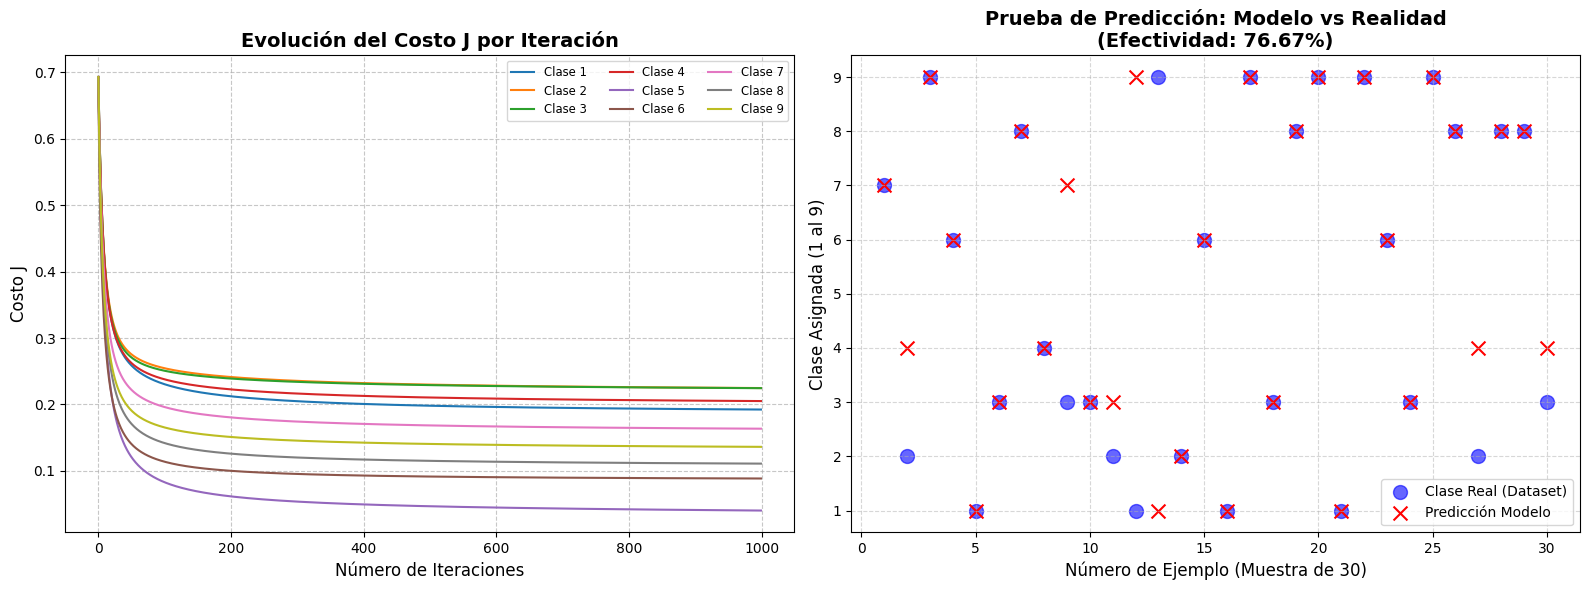

In [16]:
# Creamos un lienzo amplio con 2 espacios
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
# all_J_history tiene el costo de las 9 clases
for i in range(num_labels):
    plt.plot(all_J_history[i], label=f'Clase {i+1}')

plt.title("Evolución del Costo J por Iteración", fontsize=14, fontweight='bold')
plt.xlabel("Número de Iteraciones", fontsize=12)
plt.ylabel("Costo J", fontsize=12)
plt.legend(loc='upper right', fontsize='small', ncol=3)
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
# predicciones_muestra y y_real_muestra
eje_x = np.arange(1, 31) # Números del 1 al 30 para el eje X

# Dibujamos los puntos reales (Azules) y las predicciones (Equis Rojas)
plt.scatter(eje_x, y_real_muestra, color='blue', label='Clase Real (Dataset)', alpha=0.6, s=100)
plt.scatter(eje_x, predicciones_muestra, color='red', marker='x', label='Predicción Modelo', s=100)

plt.title(f"Prueba de Predicción: Modelo vs Realidad\n(Efectividad: {(aciertos_muestra/30)*100:.2f}%)", fontsize=14, fontweight='bold')
plt.xlabel("Número de Ejemplo (Muestra de 30)", fontsize=12)
plt.ylabel("Clase Asignada (1 al 9)", fontsize=12)
plt.yticks(range(1, 10)) # Forzamos que el eje Y muestre del 1 al 9
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()